# 03 — Communication Sentiment Analysis

VADER compound scores across 70 experiment runs. Analyzes overall tone, Boss-vs-Worker gap, phase-level shifts, and per-agent differences by leadership style.

---
## §0 — Setup & Data Loading

In [1]:
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore', category=FutureWarning)

RESULTS_DIR = Path('../results')

STYLE_ORDER = [
    'baseline', 'coercive', 'authoritative', 'affiliative',
    'democratic', 'pacesetting', 'coaching'
]

STYLE_COLORS = {
    'coercive':     '#E74C3C',
    'affiliative':  '#27AE60',
    'democratic':   '#2980B9',
    'coaching':     '#F1C40F',
    'pacesetting':  '#8E44AD',
    'authoritative':'#E67E22',
    'baseline':     '#95A5A6',
}

TASK_TYPES = ['short', 'long']
PHASE_NAMES = {1: 'Briefing', 2: 'Planning', 3: 'Coding', 4: 'Writing', 5: 'Review', 6: 'Revision'}
AGENT_ORDER = ['Boss', 'Coder', 'Writer', 'Reviewer']

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
})
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


### §0.1 — Load sentiment data

In [2]:
def parse_run_folder(name: str) -> dict | None:
    """Extract style, task, run_id from folder name."""
    m = re.match(r'^(\w+)_(short|long)_run(\d+)$', name)
    if not m:
        return None
    return {'style': m.group(1), 'task': m.group(2), 'run_id': int(m.group(3))}

# Build two DataFrames
# df_runs:  one row per run (run-level aggregates)
# df_msgs:  one row per message (message-level scores)

run_rows = []
msg_rows = []
missing = []

for folder in sorted(RESULTS_DIR.iterdir()):
    if not folder.is_dir():
        continue
    parsed = parse_run_folder(folder.name)
    if parsed is None:
        continue

    sent_path = folder / 'sentiment.json'
    if not sent_path.exists():
        missing.append(folder.name)
        continue

    try:
        sent = json.loads(sent_path.read_text())
    except (json.JSONDecodeError, UnicodeDecodeError):
        missing.append(folder.name)
        continue

    if not sent.get('valid', False):
        missing.append(folder.name)
        continue

    agg = sent.get('aggregates', {})
    run_agg = agg.get('run', {})
    bvw = agg.get('boss_vs_workers', {})

    row = {
        **parsed,
        'folder': folder.name,
        'message_count': sent.get('message_count', 0),
        'mean_compound': run_agg.get('mean_compound'),
        'median_compound': run_agg.get('median_compound'),
        'std_compound': run_agg.get('std_compound'),
        'positive_ratio': run_agg.get('positive_ratio'),
        'negative_ratio': run_agg.get('negative_ratio'),
        'boss_mean': bvw.get('boss_mean'),
        'worker_mean': bvw.get('worker_mean'),
        'sentiment_gap': bvw.get('gap'),
    }

    # Per-agent means
    per_agent = agg.get('per_agent', {})
    for agent in AGENT_ORDER:
        a = per_agent.get(agent, {})
        row[f'{agent.lower()}_sentiment'] = a.get('mean_compound')
        row[f'{agent.lower()}_msg_count'] = a.get('message_count', 0)

    # Per-phase means
    per_phase = agg.get('per_phase', {})
    for phase_num in range(1, 7):
        p = per_phase.get(str(phase_num), {})
        row[f'phase_{phase_num}_sentiment'] = p.get('mean_compound')
        row[f'phase_{phase_num}_count'] = p.get('message_count', 0)

    run_rows.append(row)

    # Per-message rows
    for msg in sent.get('messages', []):
        msg_rows.append({
            **parsed,
            'folder': folder.name,
            'seq': msg.get('seq'),
            'sender': msg.get('sender'),
            'phase': msg.get('phase'),
            'compound': msg.get('compound'),
            'positive': msg.get('positive'),
            'negative': msg.get('negative'),
            'neutral': msg.get('neutral'),
        })

df_runs = pd.DataFrame(run_rows)
df_runs['style'] = pd.Categorical(df_runs['style'], categories=STYLE_ORDER, ordered=True)
df_runs = df_runs.sort_values(['style', 'task', 'run_id']).reset_index(drop=True)

df_msgs = pd.DataFrame(msg_rows)
if len(df_msgs) > 0:
    df_msgs['style'] = pd.Categorical(df_msgs['style'], categories=STYLE_ORDER, ordered=True)

print(f'Loaded {len(df_runs)} runs with valid sentiment data')
print(f'Loaded {len(df_msgs)} individual messages')
print(f'Missing/invalid: {len(missing)}')
if missing:
    for m in missing[:5]:
        print(f'  ⚠ {m}')
    if len(missing) > 5:
        print(f'  ... and {len(missing)-5} more')

Loaded 70 runs with valid sentiment data
Loaded 1355 individual messages
Missing/invalid: 0


---
## §1 — Health Check

Total runs loaded: 70/70
Missing/invalid:   0

Completeness (runs per cell, expected=5):


task,long,short
style,,
baseline,5,5
coercive,5,5
authoritative,5,5
affiliative,5,5
democratic,5,5
pacesetting,5,5
coaching,5,5



Compound score range: [-0.172, 0.986]
Overall mean: 0.666 ± 0.276
Positive ratio mean: 85.24%
Negative ratio mean: 14.19%

Message count per run: mean=19.4, min=12, max=23


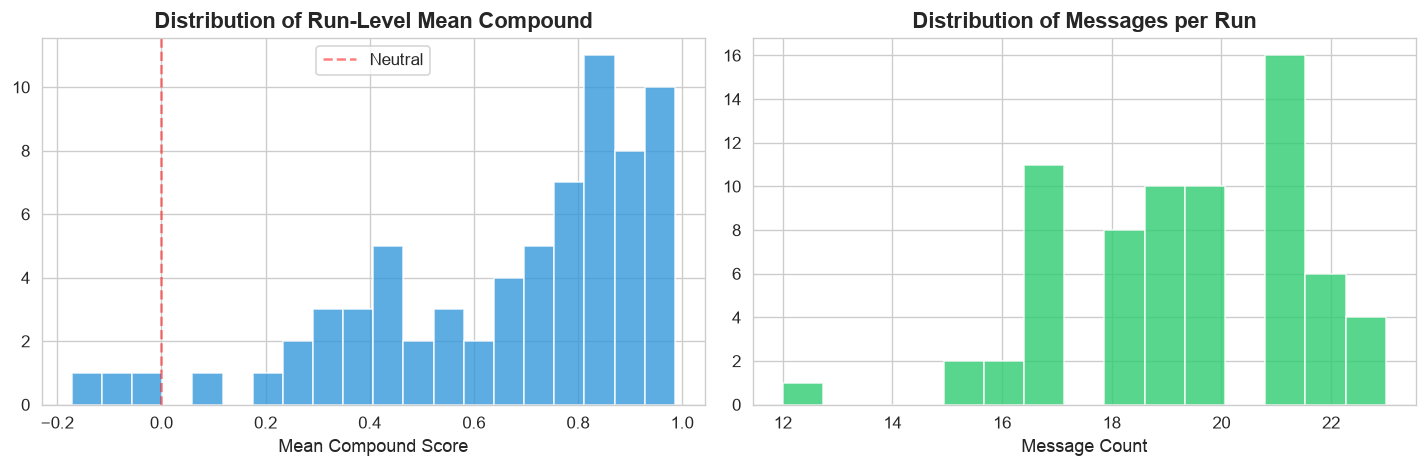

In [3]:
# §1a: Missing/invalid sentiment files

print(f'Total runs loaded: {len(df_runs)}/70')
print(f'Missing/invalid:   {len(missing)}')
print()

# Completeness grid
completeness = df_runs.groupby(['style', 'task'], observed=True).size().unstack(fill_value=0)
print('Completeness (runs per cell, expected=5):')
display(completeness)

# §1b: Score distribution sanity check
print(f'\nCompound score range: [{df_runs["mean_compound"].min():.3f}, {df_runs["mean_compound"].max():.3f}]')
print(f'Overall mean: {df_runs["mean_compound"].mean():.3f} ± {df_runs["mean_compound"].std():.3f}')
print(f'Positive ratio mean: {df_runs["positive_ratio"].mean():.2%}')
print(f'Negative ratio mean: {df_runs["negative_ratio"].mean():.2%}')

# §1c: Message count distribution
print(f'\nMessage count per run: mean={df_runs["message_count"].mean():.1f}, '
      f'min={df_runs["message_count"].min()}, max={df_runs["message_count"].max()}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_runs['mean_compound'].hist(bins=20, ax=axes[0], color='#3498DB', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribution of Run-Level Mean Compound', fontweight='bold')
axes[0].set_xlabel('Mean Compound Score')
axes[0].axvline(0, color='red', linestyle='--', alpha=0.5, label='Neutral')
axes[0].legend()

df_runs['message_count'].hist(bins=15, ax=axes[1], color='#2ECC71', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribution of Messages per Run', fontweight='bold')
axes[1].set_xlabel('Message Count')

plt.tight_layout()
plt.show()

---
## §2 — Overall Sentiment by Style

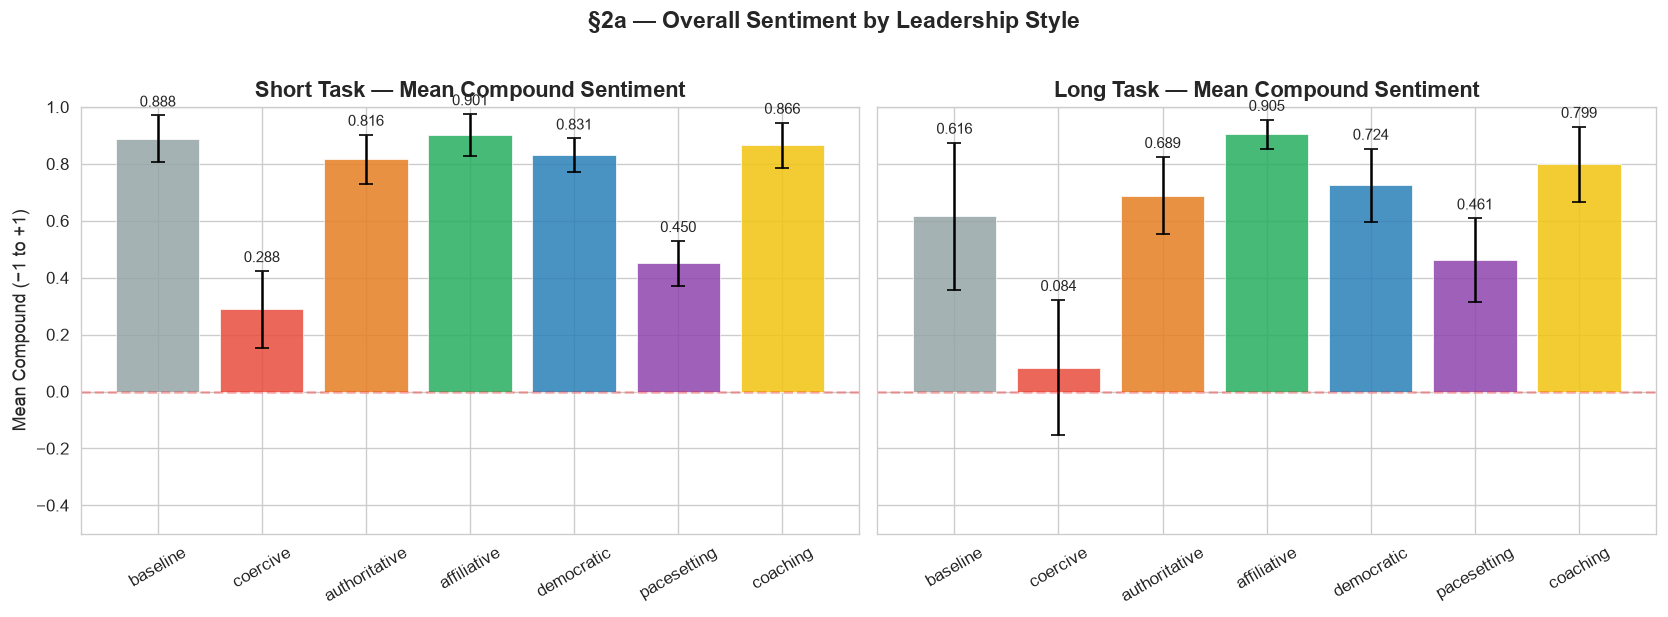

In [4]:
# §2a: Bar chart — mean compound per style

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, task in zip(axes, TASK_TYPES):
    sub = df_runs[df_runs['task'] == task]
    means = sub.groupby('style', observed=True)['mean_compound'].mean()
    stds  = sub.groupby('style', observed=True)['mean_compound'].std()
    colors = [STYLE_COLORS[s] for s in means.index]

    bars = ax.bar(means.index, means, yerr=stds, capsize=4,
                  color=colors, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_title(f'{task.title()} Task — Mean Compound Sentiment', fontweight='bold')
    ax.set_ylabel('Mean Compound (−1 to +1)' if task == 'short' else '')
    ax.set_ylim(-0.5, 1.0)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3, label='Neutral')
    ax.tick_params(axis='x', rotation=30)

    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.02,
                f'{m:.3f}', ha='center', va='bottom', fontsize=9)

fig.suptitle('§2a — Overall Sentiment by Leadership Style', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

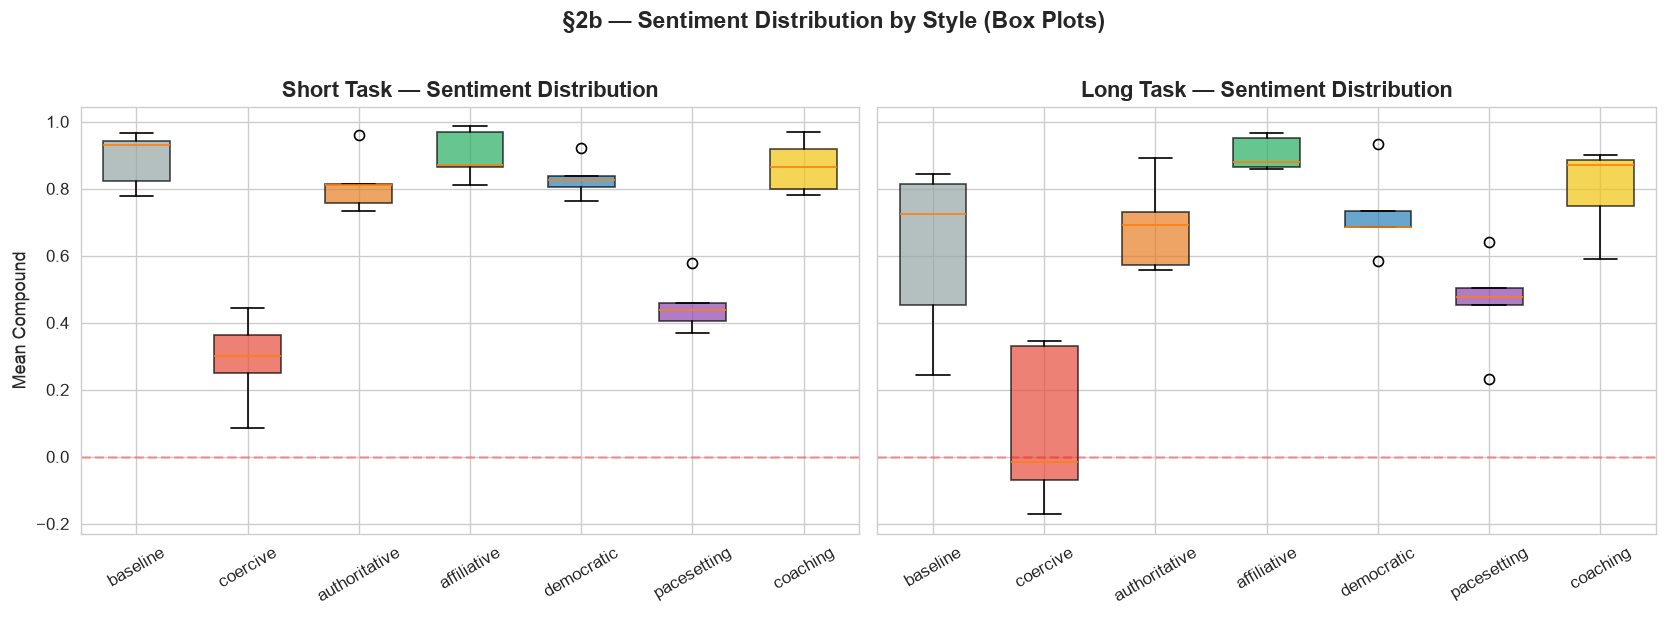

In [5]:
# §2b: Box plots — run-level distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, task in zip(axes, TASK_TYPES):
    sub = df_runs[df_runs['task'] == task]
    data = [sub.loc[sub['style'] == s, 'mean_compound'].dropna().values for s in STYLE_ORDER]
    bp = ax.boxplot(data, tick_labels=STYLE_ORDER, patch_artist=True, widths=0.6)

    for patch, style in zip(bp['boxes'], STYLE_ORDER):
        patch.set_facecolor(STYLE_COLORS[style])
        patch.set_alpha(0.7)

    ax.set_title(f'{task.title()} Task — Sentiment Distribution', fontweight='bold')
    ax.set_ylabel('Mean Compound' if task == 'short' else '')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('§2b — Sentiment Distribution by Style (Box Plots)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## §3 — Boss vs Workers Sentiment

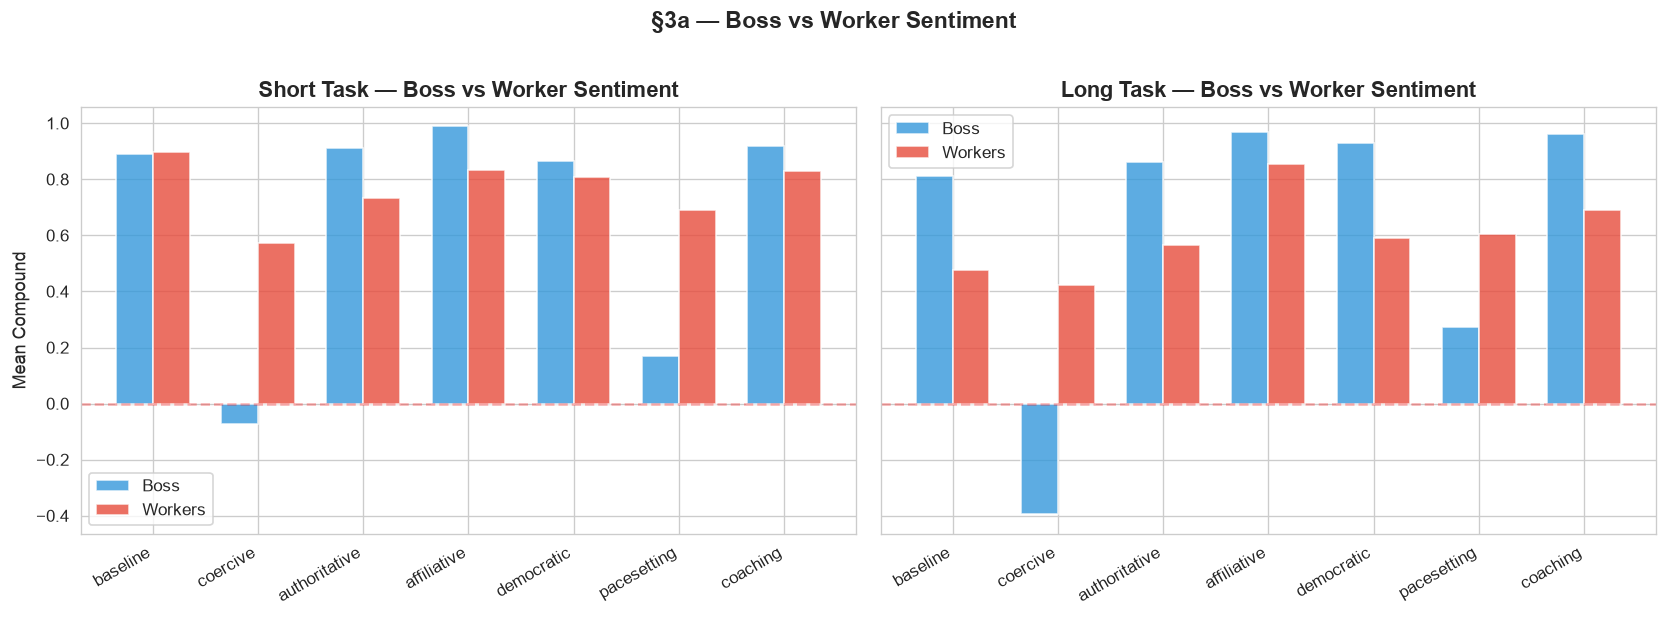

In [6]:
# §3a: Grouped bar — Boss mean vs Worker mean per style

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, task in zip(axes, TASK_TYPES):
    sub = df_runs[df_runs['task'] == task]
    boss_means   = sub.groupby('style', observed=True)['boss_mean'].mean().reindex(STYLE_ORDER)
    worker_means = sub.groupby('style', observed=True)['worker_mean'].mean().reindex(STYLE_ORDER)

    x = np.arange(len(STYLE_ORDER))
    width = 0.35

    ax.bar(x - width/2, boss_means, width, label='Boss', color='#3498DB', alpha=0.8, edgecolor='white')
    ax.bar(x + width/2, worker_means, width, label='Workers', color='#E74C3C', alpha=0.8, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(STYLE_ORDER, rotation=30, ha='right')
    ax.set_title(f'{task.title()} Task — Boss vs Worker Sentiment', fontweight='bold')
    ax.set_ylabel('Mean Compound' if task == 'short' else '')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.legend()

fig.suptitle('§3a — Boss vs Worker Sentiment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

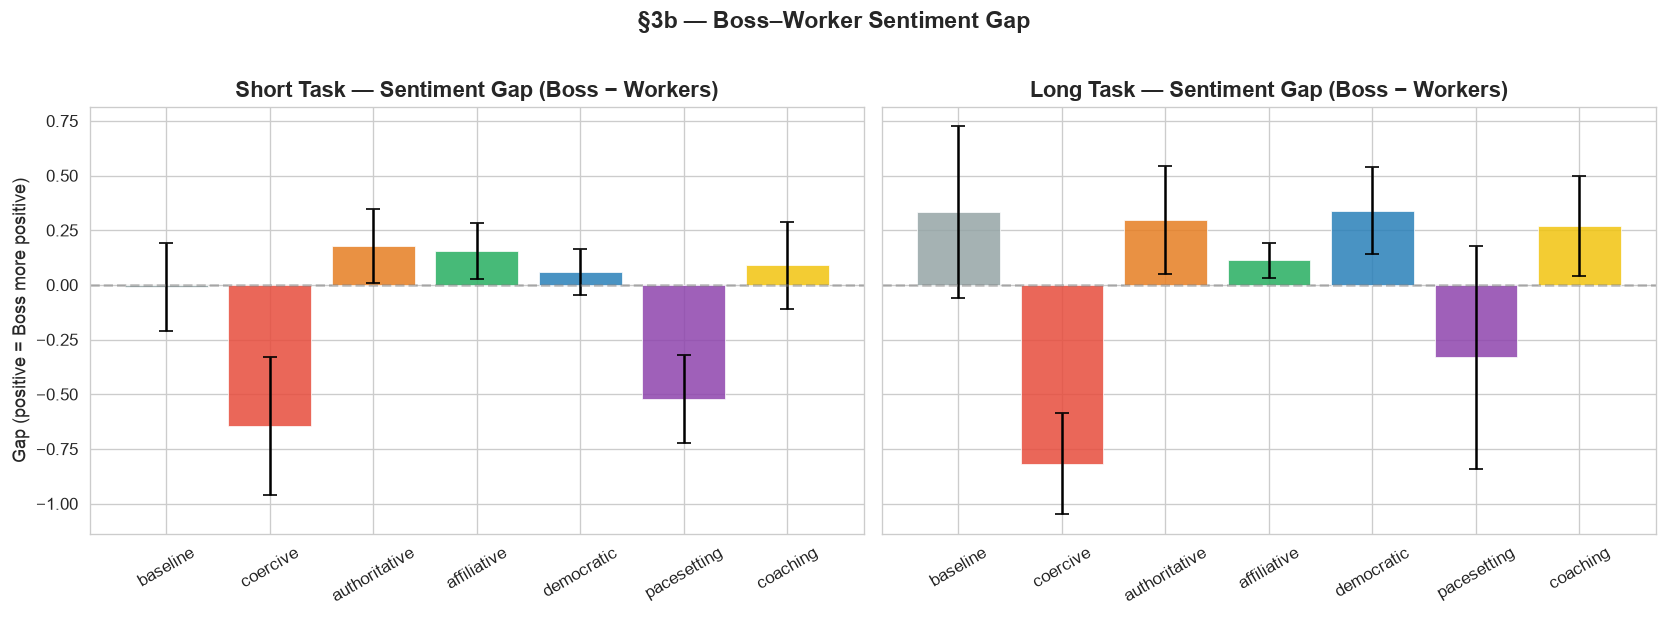

In [7]:
# §3b: Sentiment gap (boss − worker) per style

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, task in zip(axes, TASK_TYPES):
    sub = df_runs[df_runs['task'] == task]
    gap_means = sub.groupby('style', observed=True)['sentiment_gap'].mean().reindex(STYLE_ORDER)
    gap_stds  = sub.groupby('style', observed=True)['sentiment_gap'].std().reindex(STYLE_ORDER)
    colors = [STYLE_COLORS[s] for s in STYLE_ORDER]

    bars = ax.bar(STYLE_ORDER, gap_means, yerr=gap_stds, capsize=4,
                  color=colors, edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.set_title(f'{task.title()} Task — Sentiment Gap (Boss − Workers)', fontweight='bold')
    ax.set_ylabel('Gap (positive = Boss more positive)' if task == 'short' else '')
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('§3b — Boss–Worker Sentiment Gap', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## §4 — Phase-Level Sentiment

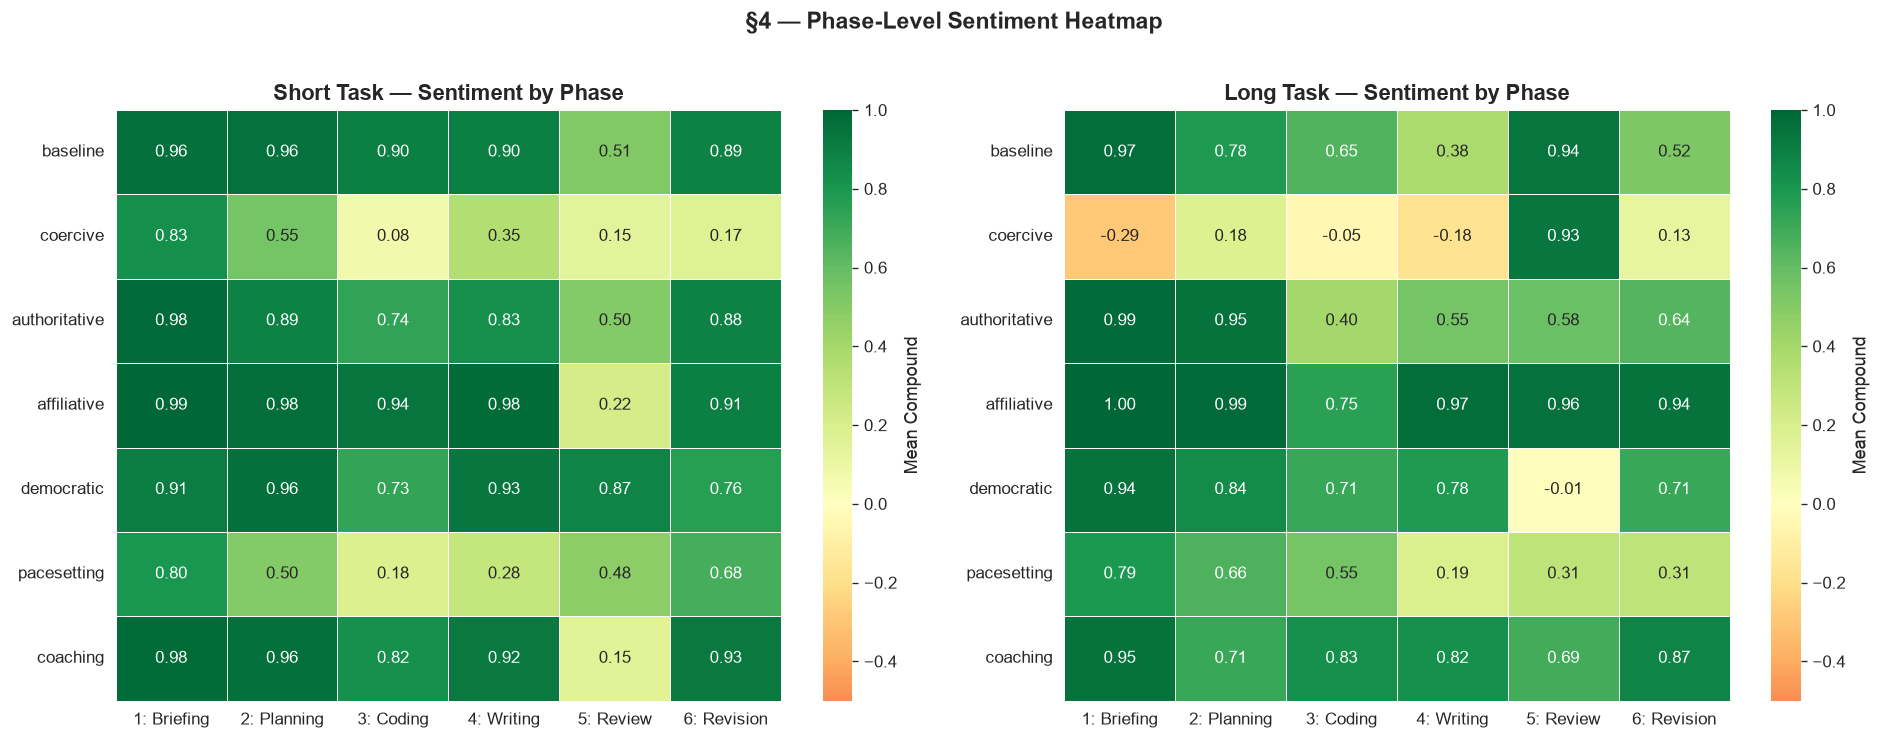


Phase 5-6 (Review/Revision) sentiment vs Phase 1-4 average:
  Short: Phase 1-4 avg = 0.779, Phase 5-6 avg = 0.578, drop = 0.202
  Long: Phase 1-4 avg = 0.636, Phase 5-6 avg = 0.609, drop = 0.027


In [8]:
# §4: Heatmap — styles × phases → mean compound

phase_cols = [f'phase_{p}_sentiment' for p in range(1, 7)]
phase_labels = [f'{p}: {PHASE_NAMES[p]}' for p in range(1, 7)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, task in zip(axes, TASK_TYPES):
    sub = df_runs[df_runs['task'] == task]
    pivot = sub.groupby('style', observed=True)[phase_cols].mean()
    pivot.columns = phase_labels
    pivot = pivot.reindex(STYLE_ORDER)

    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                vmin=-0.5, vmax=1.0, linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Mean Compound'})
    ax.set_title(f'{task.title()} Task — Sentiment by Phase', fontweight='bold')
    ax.set_ylabel('')

fig.suptitle('§4 — Phase-Level Sentiment Heatmap', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Highlight Review/Revision drops
print('\nPhase 5-6 (Review/Revision) sentiment vs Phase 1-4 average:')
for task in TASK_TYPES:
    sub = df_runs[df_runs['task'] == task]
    early = sub[[f'phase_{p}_sentiment' for p in range(1, 5)]].mean(axis=1).mean()
    late  = sub[[f'phase_{p}_sentiment' for p in range(5, 7)]].mean(axis=1).mean()
    print(f'  {task.title()}: Phase 1-4 avg = {early:.3f}, Phase 5-6 avg = {late:.3f}, '
          f'drop = {early - late:.3f}')

---
## §5 — Per-Agent Sentiment

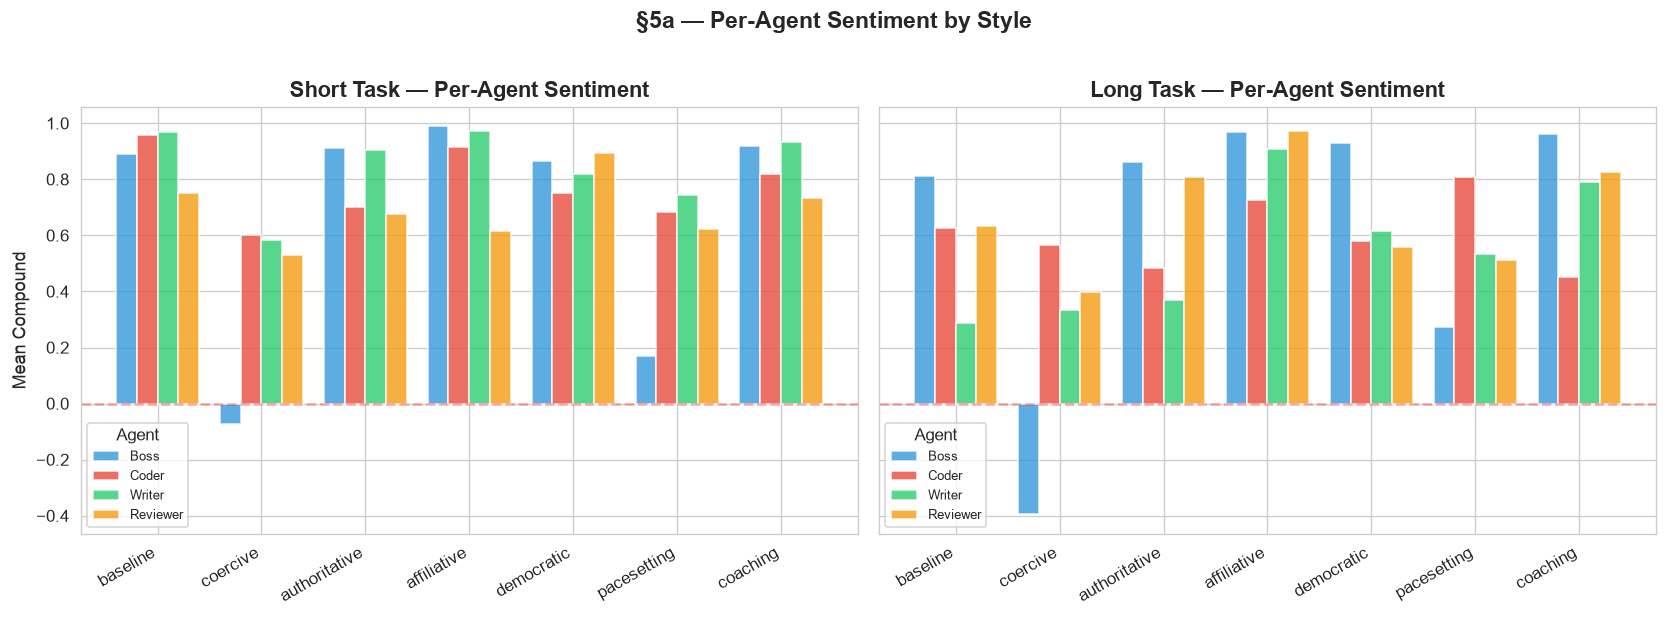

In [9]:
# §5a: Grouped bar — per-agent mean across styles

agent_sent_cols = [f'{a.lower()}_sentiment' for a in AGENT_ORDER]
agent_colors_map = {'Boss': '#3498DB', 'Coder': '#E74C3C', 'Writer': '#2ECC71', 'Reviewer': '#F39C12'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, task in zip(axes, TASK_TYPES):
    sub = df_runs[df_runs['task'] == task]
    x = np.arange(len(STYLE_ORDER))
    width = 0.2

    for i, (agent, col) in enumerate(zip(AGENT_ORDER, agent_sent_cols)):
        means = sub.groupby('style', observed=True)[col].mean().reindex(STYLE_ORDER)
        ax.bar(x + i * width, means, width, label=agent,
               color=agent_colors_map[agent], alpha=0.8, edgecolor='white')

    ax.set_xticks(x + 1.5 * width)
    ax.set_xticklabels(STYLE_ORDER, rotation=30, ha='right')
    ax.set_title(f'{task.title()} Task — Per-Agent Sentiment', fontweight='bold')
    ax.set_ylabel('Mean Compound' if task == 'short' else '')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.legend(title='Agent', fontsize=8)

fig.suptitle('§5a — Per-Agent Sentiment by Style', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

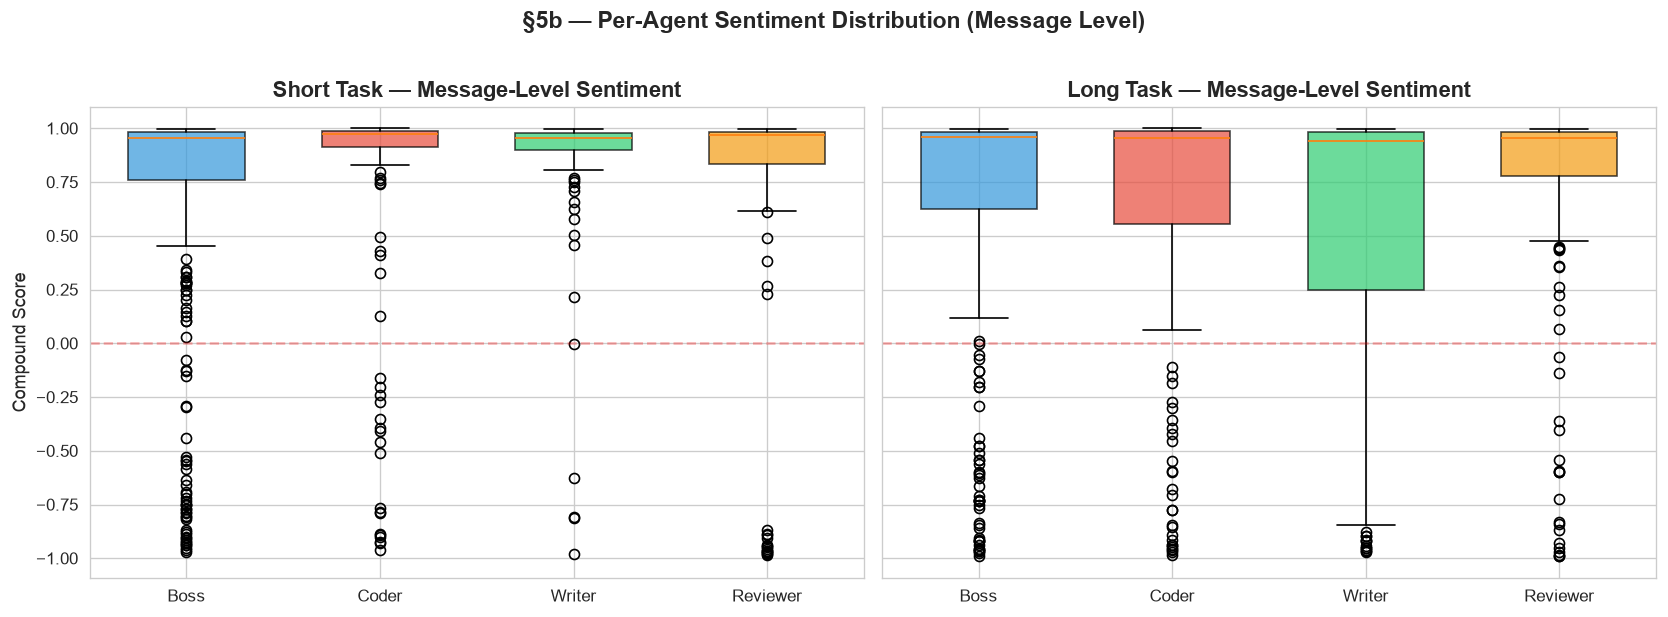


Agent sentiment means (across all runs):
        Boss: mean=0.651, median=0.954, n=577
       Coder: mean=0.682, median=0.965, n=290
      Writer: mean=0.662, median=0.950, n=234
    Reviewer: mean=0.683, median=0.959, n=254


In [10]:
# §5b: Box plots — per-agent distributions

if len(df_msgs) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    for ax, task in zip(axes, TASK_TYPES):
        sub = df_msgs[df_msgs['task'] == task]
        data = [sub.loc[sub['sender'] == agent, 'compound'].dropna().values for agent in AGENT_ORDER]
        bp = ax.boxplot(data, tick_labels=AGENT_ORDER, patch_artist=True, widths=0.6)

        for patch, agent in zip(bp['boxes'], AGENT_ORDER):
            patch.set_facecolor(agent_colors_map[agent])
            patch.set_alpha(0.7)

        ax.set_title(f'{task.title()} Task — Message-Level Sentiment', fontweight='bold')
        ax.set_ylabel('Compound Score' if task == 'short' else '')
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)

    fig.suptitle('§5b — Per-Agent Sentiment Distribution (Message Level)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Check if Writer is consistently most negative
    print('\nAgent sentiment means (across all runs):')
    for agent in AGENT_ORDER:
        agent_msgs = df_msgs[df_msgs['sender'] == agent]['compound']
        print(f'  {agent:>10}: mean={agent_msgs.mean():.3f}, median={agent_msgs.median():.3f}, '
              f'n={len(agent_msgs)}')
else:
    print('No message-level data available.')

---
## §6 — Sentiment Trajectory

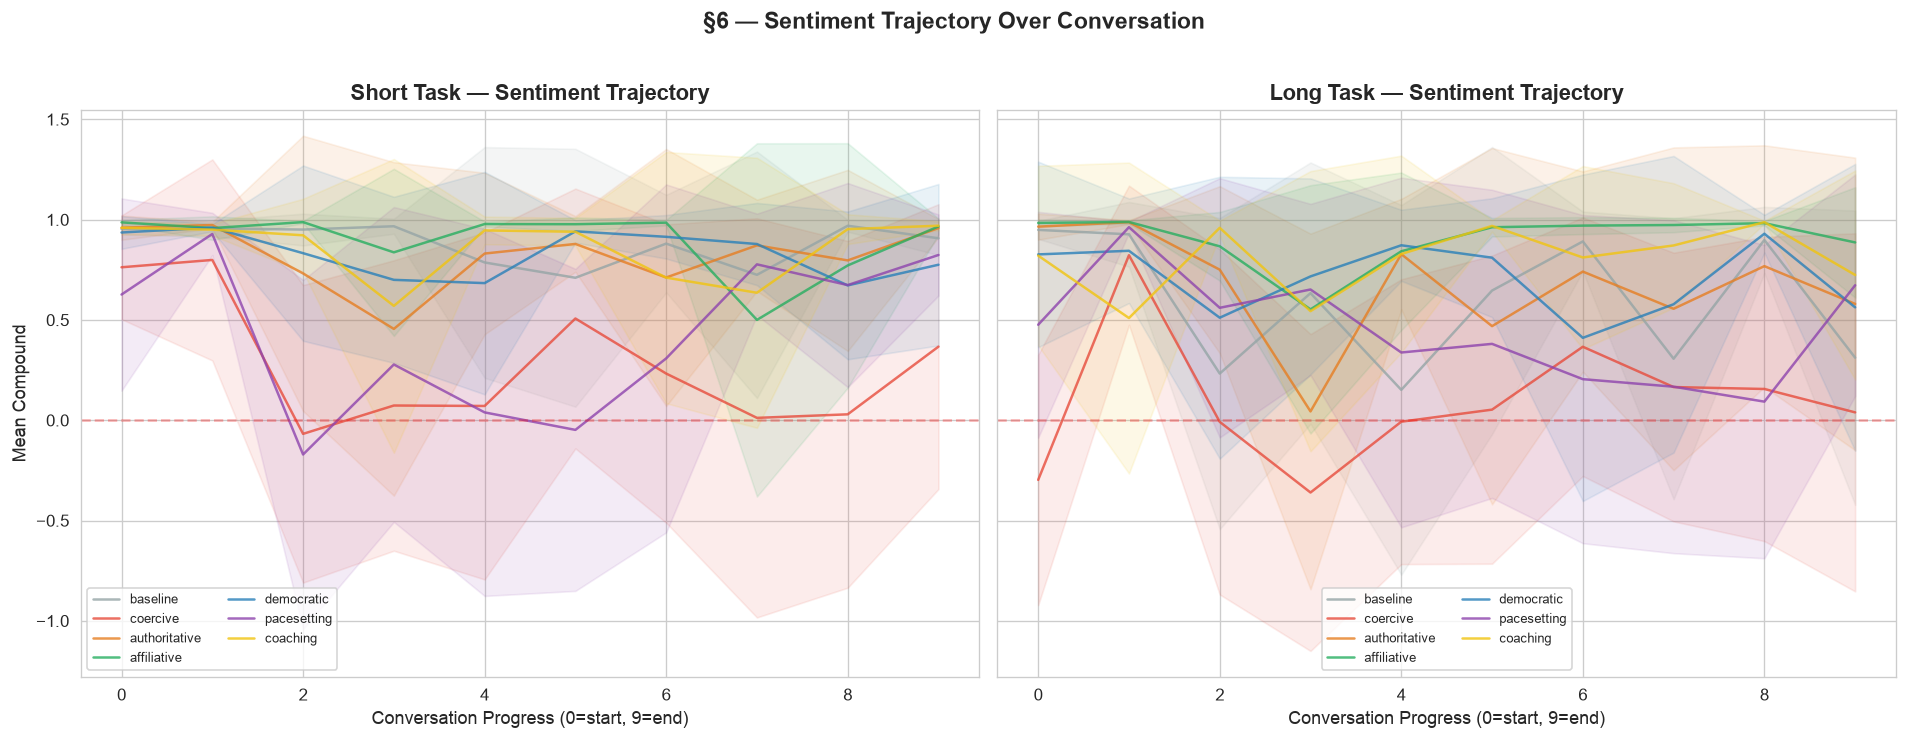

In [11]:
# §6: Line chart — compound over message sequence

if len(df_msgs) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    for ax, task in zip(axes, TASK_TYPES):
        sub = df_msgs[df_msgs['task'] == task]

        for style in STYLE_ORDER:
            style_msgs = sub[sub['style'] == style].copy()
            if len(style_msgs) == 0:
                continue

            # Normalize sequence to 0-1 range per run, then bin
            runs = style_msgs.groupby('folder')
            normalized = []
            for _, run_msgs in runs:
                run_msgs = run_msgs.sort_values('seq')
                n = len(run_msgs)
                if n > 0:
                    run_msgs = run_msgs.copy()
                    run_msgs['norm_pos'] = np.linspace(0, 1, n)
                    normalized.append(run_msgs)

            if not normalized:
                continue

            all_norm = pd.concat(normalized)
            # Bin into 10 segments
            all_norm['bin'] = pd.cut(all_norm['norm_pos'], bins=10, labels=False)
            binned = all_norm.groupby('bin')['compound'].agg(['mean', 'std'])

            ax.plot(binned.index, binned['mean'], color=STYLE_COLORS[style],
                    label=style, linewidth=1.5, alpha=0.8)
            ax.fill_between(binned.index,
                           binned['mean'] - binned['std'],
                           binned['mean'] + binned['std'],
                           color=STYLE_COLORS[style], alpha=0.1)

        ax.set_xlabel('Conversation Progress (0=start, 9=end)')
        ax.set_ylabel('Mean Compound' if task == 'short' else '')
        ax.set_title(f'{task.title()} Task — Sentiment Trajectory', fontweight='bold')
        ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
        ax.legend(fontsize=8, ncol=2)

    fig.suptitle('§6 — Sentiment Trajectory Over Conversation', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No message-level data available for trajectory analysis.')

---
## §7 — Short vs Long Task Comparison

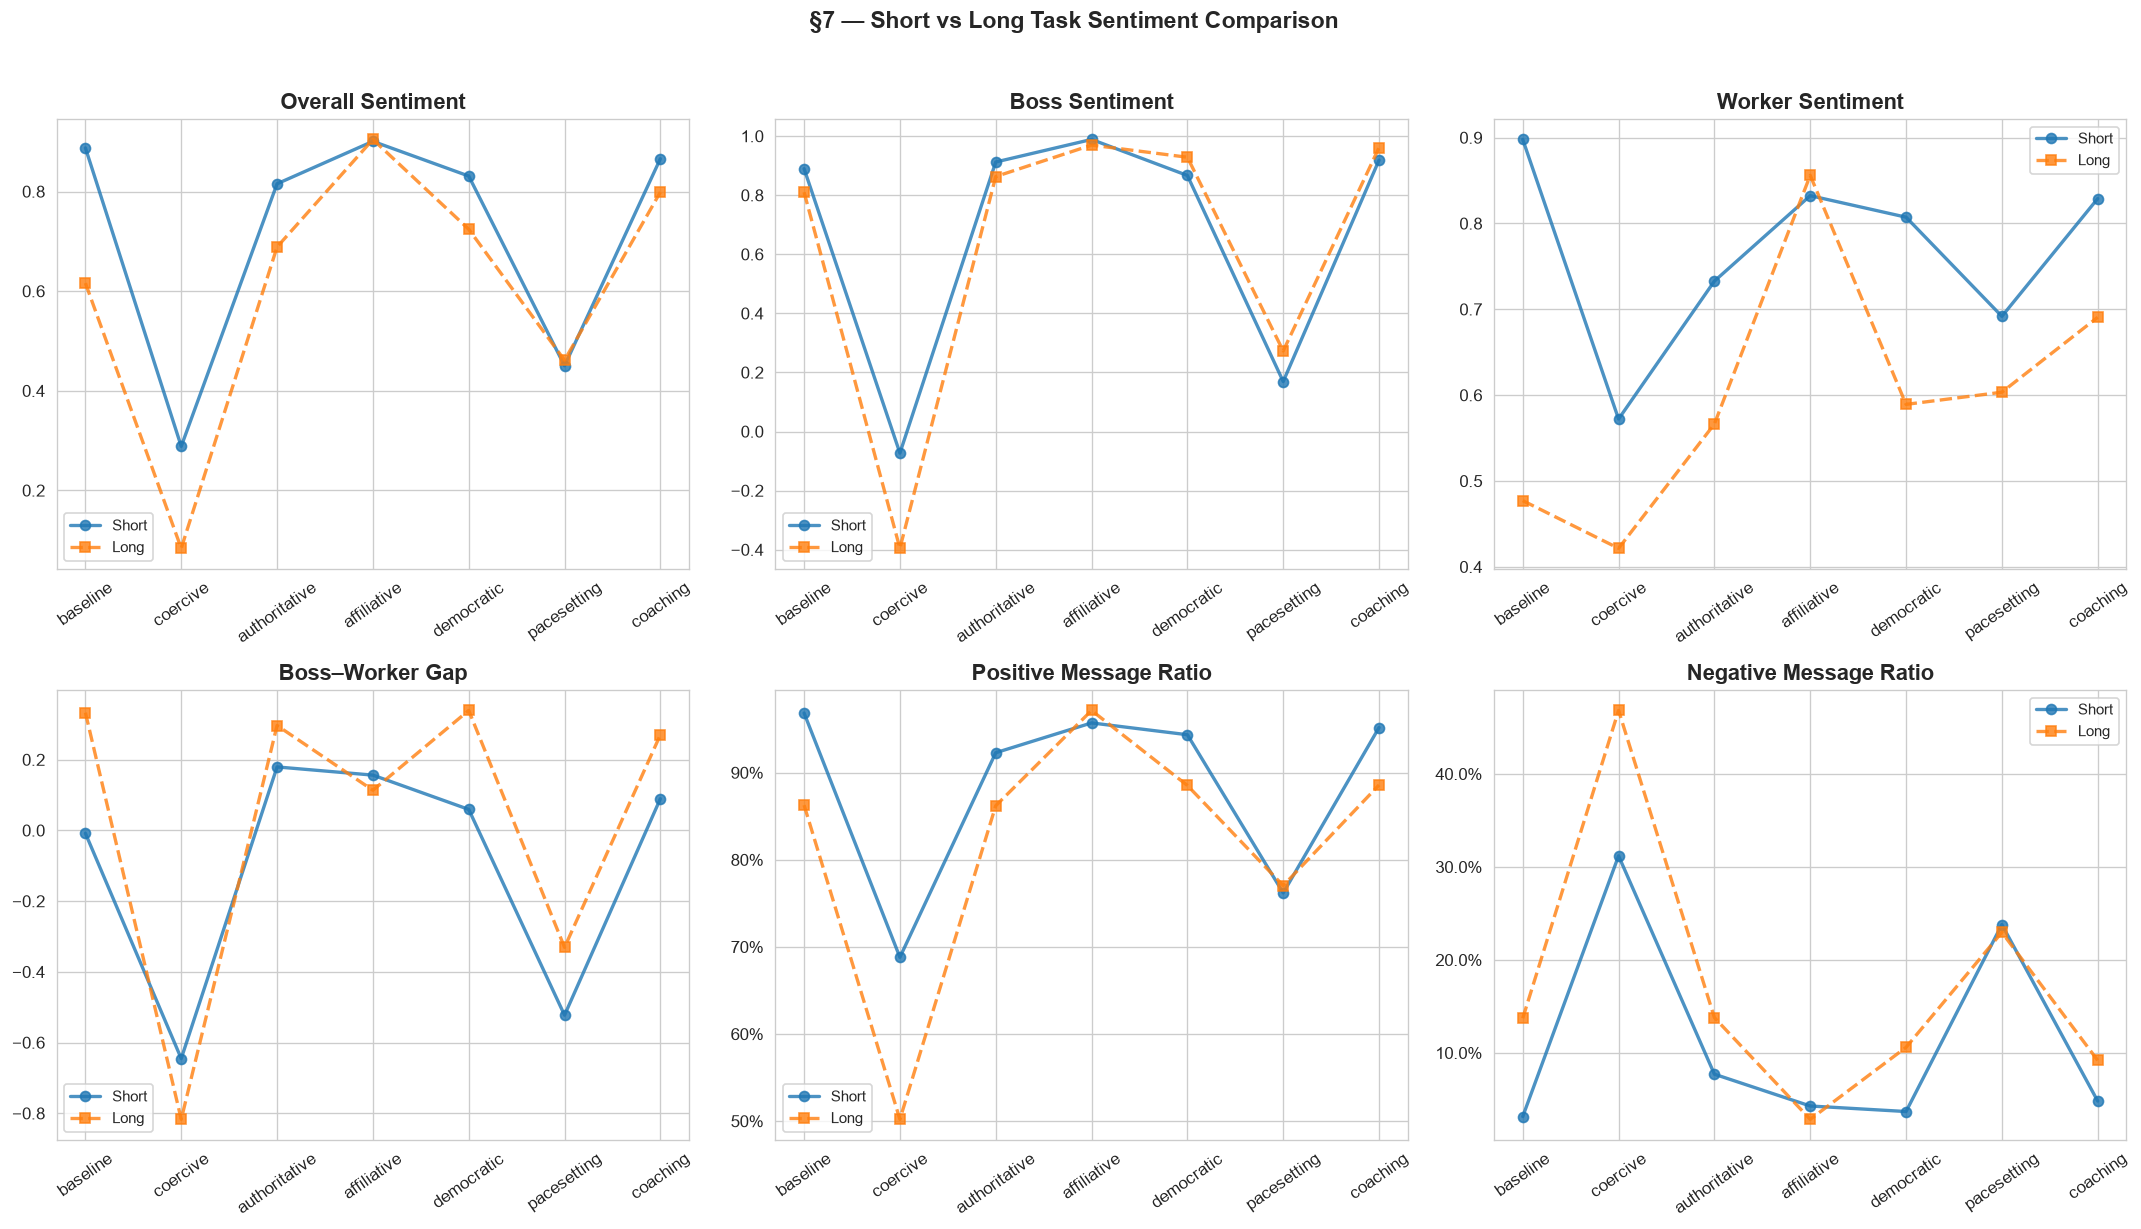


Sentiment Summary: Short vs Long


mean_compound        boss_mean        worker_mean        sentiment_gap  \
               mean    std      mean    std        mean    std          mean   
task                                                                           
long          0.611  0.297     0.630  0.503       0.601  0.271         0.029   
short         0.720  0.244     0.668  0.421       0.766  0.159        -0.099   

              
         std  
task          
long   0.496  
short  0.366

In [12]:
# §7: Side-by-side comparison of key sentiment metrics

compare_metrics = [
    ('mean_compound',   'Overall Sentiment'),
    ('boss_mean',       'Boss Sentiment'),
    ('worker_mean',     'Worker Sentiment'),
    ('sentiment_gap',   'Boss–Worker Gap'),
    ('positive_ratio',  'Positive Message Ratio'),
    ('negative_ratio',  'Negative Message Ratio'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, (metric, label) in zip(axes.flat, compare_metrics):
    for task, marker, ls in [('short', 'o', '-'), ('long', 's', '--')]:
        sub = df_runs[df_runs['task'] == task]
        means = sub.groupby('style', observed=True)[metric].mean().reindex(STYLE_ORDER)
        ax.plot(STYLE_ORDER, means, marker=marker, linestyle=ls, label=f'{task.title()}',
                linewidth=2, markersize=6, alpha=0.8)

    ax.set_title(label, fontweight='bold')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(fontsize=9)
    if 'ratio' in metric.lower():
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.suptitle('§7 — Short vs Long Task Sentiment Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print('\nSentiment Summary: Short vs Long')
summary = df_runs.groupby('task')[['mean_compound', 'boss_mean', 'worker_mean', 'sentiment_gap']].agg(['mean', 'std'])
display(summary.round(3))

---
## §8 — Statistical Tests

Kruskal-Wallis H-test followed by pairwise Mann-Whitney U where significant. Note: n=5 per condition; effect sizes more informative than p-values.

In [13]:
# §8: Kruskal-Wallis for sentiment metrics

def rank_biserial(group_a, group_b):
    """Compute rank-biserial effect size for Mann-Whitney U."""
    u_stat, _ = stats.mannwhitneyu(group_a, group_b, alternative='two-sided')
    n1, n2 = len(group_a), len(group_b)
    return 1 - (2 * u_stat) / (n1 * n2)

sent_test_metrics = [
    ('mean_compound',    'Overall Sentiment'),
    ('boss_mean',        'Boss Sentiment'),
    ('worker_mean',      'Worker Sentiment'),
    ('sentiment_gap',    'Boss–Worker Gap'),
    ('positive_ratio',   'Positive Ratio'),
    ('negative_ratio',   'Negative Ratio'),
]

print('=' * 80)
print('§8 — STATISTICAL TESTS (Kruskal-Wallis H-test across 7 leadership styles)')
print('=' * 80)
print(f'{"Caveat:":>10} n=5 per condition — limited power. Focus on effect sizes.')
print()

kw_sent_results = []

for task in TASK_TYPES:
    print(f'\n{"─" * 40}')
    print(f'  {task.upper()} TASK')
    print(f'{"─" * 40}')

    sub = df_runs[df_runs['task'] == task]

    for metric, label in sent_test_metrics:
        if metric not in sub.columns or sub[metric].isna().all():
            continue

        groups = [g[metric].dropna().values for _, g in sub.groupby('style', observed=True)]
        groups = [g for g in groups if len(g) > 0]

        if len(groups) < 2:
            continue

        h_stat, p_val = stats.kruskal(*groups)
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''

        kw_sent_results.append({
            'task': task, 'metric': label,
            'H': h_stat, 'p': p_val, 'sig': sig
        })

        print(f'  {label:.<30} H={h_stat:7.3f}  p={p_val:.4f}  {sig}')

print()
print('Significance: * p<.05, ** p<.01, *** p<.001')

kw_sent_df = pd.DataFrame(kw_sent_results)
print('\n\nKruskal-Wallis Summary Table:')
display(kw_sent_df.style.format({'H': '{:.3f}', 'p': '{:.4f}'}))

§8 — STATISTICAL TESTS (Kruskal-Wallis H-test across 7 leadership styles)
   Caveat: n=5 per condition — limited power. Focus on effect sizes.


────────────────────────────────────────
  SHORT TASK
────────────────────────────────────────
  Overall Sentiment............. H= 23.699  p=0.0006  ***
  Boss Sentiment................ H= 27.859  p=0.0001  ***
  Worker Sentiment.............. H= 12.072  p=0.0604  
  Boss–Worker Gap............... H= 22.720  p=0.0009  ***
  Positive Ratio................ H= 23.224  p=0.0007  ***
  Negative Ratio................ H= 23.579  p=0.0006  ***

────────────────────────────────────────
  LONG TASK
────────────────────────────────────────
  Overall Sentiment............. H= 23.051  p=0.0008  ***
  Boss Sentiment................ H= 27.250  p=0.0001  ***
  Worker Sentiment.............. H=  8.000  p=0.2381  
  Boss–Worker Gap............... H= 17.806  p=0.0067  **
  Positive Ratio................ H= 19.649  p=0.0032  **
  Negative Ratio................ H=

,task,metric,H,p,sig
0,short,Overall Sentiment,23.699,0.0006,***
1,short,Boss Sentiment,27.859,0.0001,***
2,short,Worker Sentiment,12.072,0.0604,
3,short,Boss–Worker Gap,22.720,0.0009,***
4,short,Positive Ratio,23.224,0.0007,***
5,short,Negative Ratio,23.579,0.0006,***
6,long,Overall Sentiment,23.051,0.0008,***
7,long,Boss Sentiment,27.250,0.0001,***
8,long,Worker Sentiment,8.000,0.2381,
9,long,Boss–Worker Gap,17.806,0.0067,**


In [14]:
# §8 (cont.): Pairwise Mann-Whitney U for significant results

sig_sent = [r for r in kw_sent_results if r['p'] < 0.05]

if not sig_sent:
    print('No significant Kruskal-Wallis results — skipping pairwise comparisons.')
    print('(This is expected with n=5 per condition.)')
else:
    print('=' * 80)
    print('PAIRWISE COMPARISONS (Mann-Whitney U + rank-biserial effect size)')
    print('=' * 80)
    print('Only showing pairs with p < 0.05.')
    print()

    for r in sig_sent:
        task = r['task']
        metric = [m for m, l in sent_test_metrics if l == r['metric']][0]
        sub = df_runs[df_runs['task'] == task]

        print(f'\n  {r["metric"]} ({task} task) — H={r["H"]:.3f}, p={r["p"]:.4f}')
        print(f'  {"Style A":>15}  vs  {"Style B":<15}  {"U":>8}  {"p":>8}  {"r_rb":>8}  {"sig":>4}')

        styles_present = [s for s in STYLE_ORDER if s in sub['style'].values]

        for i, sa in enumerate(styles_present):
            for sb in styles_present[i+1:]:
                ga = sub.loc[sub['style'] == sa, metric].dropna()
                gb = sub.loc[sub['style'] == sb, metric].dropna()
                if len(ga) < 2 or len(gb) < 2:
                    continue
                u, p = stats.mannwhitneyu(ga, gb, alternative='two-sided')
                if p < 0.05:
                    r_rb = rank_biserial(ga.values, gb.values)
                    sig = '*' if p < 0.05 else ''
                    print(f'  {sa:>15}  vs  {sb:<15}  {u:8.1f}  {p:8.4f}  {r_rb:8.3f}  {sig:>4}')

PAIRWISE COMPARISONS (Mann-Whitney U + rank-biserial effect size)
Only showing pairs with p < 0.05.


  Overall Sentiment (short task) — H=23.699, p=0.0006
          Style A  vs  Style B                 U         p      r_rb   sig
         baseline  vs  coercive             25.0    0.0079    -1.000     *
         baseline  vs  pacesetting          25.0    0.0079    -1.000     *
         coercive  vs  authoritative         0.0    0.0079     1.000     *
         coercive  vs  affiliative           0.0    0.0079     1.000     *
         coercive  vs  democratic            0.0    0.0079     1.000     *
         coercive  vs  coaching              0.0    0.0079     1.000     *
    authoritative  vs  pacesetting          25.0    0.0079    -1.000     *
      affiliative  vs  pacesetting          25.0    0.0079    -1.000     *
       democratic  vs  pacesetting          25.0    0.0079    -1.000     *
      pacesetting  vs  coaching              0.0    0.0079     1.000     *

  Boss Sentiment (